<h1>Train — InceptionNet v3</h1>

Trains and evaluates InceptionNet v3 using the tuned hyperparameters from `ARCH_HYPERPARAMS["inception_v3"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): CapeFlats
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 785 | Val: 192 | Test: 766


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["inception_v3"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"InceptionNet v3: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

InceptionNet v3: micro batch = 8, accumulation steps = 1 (effective batch size ≈ 8, tuned value = 8)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with InceptionNet v3)
# ---------------------------------------------------------
model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)

in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

# The auxiliary classifier (used only during training, see run_epoch in
# wwtw_utils.py) also needs its output layer resized to our number of classes.
in_f_aux = model.AuxLogits.fc.in_features
model.AuxLogits.fc = nn.Linear(in_f_aux, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[InceptionNet v3] Epoch   1/100 | LR: 2.85e-04 | train loss 1.4646 acc 0.621 | val loss 0.7334 acc 0.750 *


[InceptionNet v3] Epoch   2/100 | LR: 2.85e-04 | train loss 1.3339 acc 0.721 | val loss 0.7508 acc 0.729


[InceptionNet v3] Epoch   3/100 | LR: 2.85e-04 | train loss 1.3239 acc 0.634 | val loss 0.8812 acc 0.714


[InceptionNet v3] Epoch   4/100 | LR: 2.85e-04 | train loss 1.2911 acc 0.685 | val loss 0.7078 acc 0.755 *


[InceptionNet v3] Epoch   5/100 | LR: 2.85e-04 | train loss 1.2501 acc 0.680 | val loss 0.8153 acc 0.729


...

[InceptionNet v3] Epoch  32/100 | LR: 2.85e-04 | train loss 0.6969 acc 0.835 | val loss 0.5591 acc 0.792


[InceptionNet v3] Epoch  33/100 | LR: 2.85e-05 | train loss 0.6594 acc 0.834 | val loss 0.4942 acc 0.792


[InceptionNet v3] Epoch  34/100 | LR: 2.85e-05 | train loss 0.5674 acc 0.879 | val loss 0.5296 acc 0.786


[InceptionNet v3] Epoch  35/100 | LR: 2.85e-05 | train loss 0.4529 acc 0.907 | val loss 0.5217 acc 0.792


[InceptionNet v3] Epoch  36/100 | LR: 2.85e-05 | train loss 0.4115 acc 0.911 | val loss 0.5213 acc 0.792

[InceptionNet v3] No val loss improvement for 10 epochs — stopping early at epoch 36.

[InceptionNet v3] Restored best checkpoint (val loss = 0.3850)


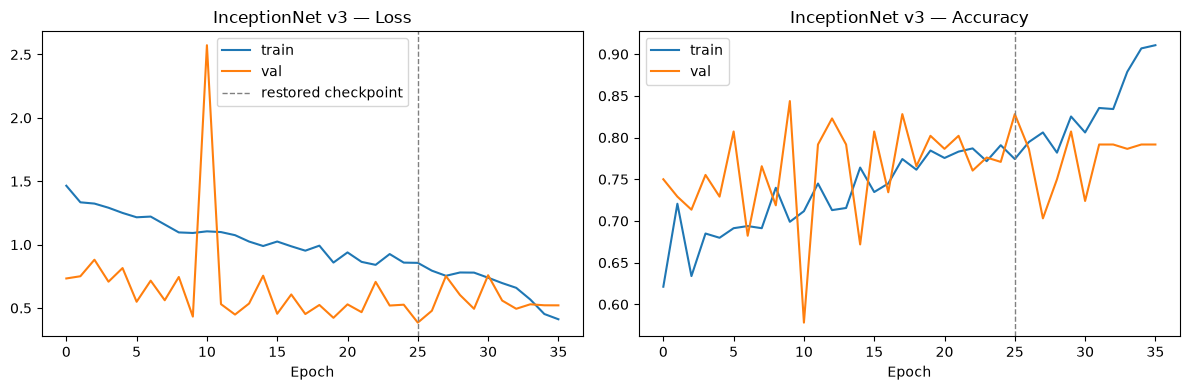

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "InceptionNet v3", is_inception=True,
    accum_steps=accum_steps,
)
plot_training_curves(history, "InceptionNet v3")

## Evaluate on the test set

[InceptionNet v3] Test accuracy: 0.551


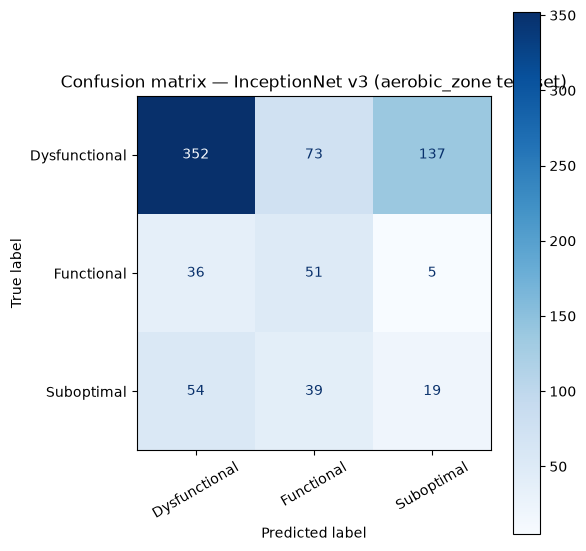

               precision    recall  f1-score   support

Dysfunctional      0.796     0.626     0.701       562
   Functional      0.313     0.554     0.400        92
   Suboptimal      0.118     0.170     0.139       112

     accuracy                          0.551       766
    macro avg      0.409     0.450     0.413       766
 weighted avg      0.639     0.551     0.583       766



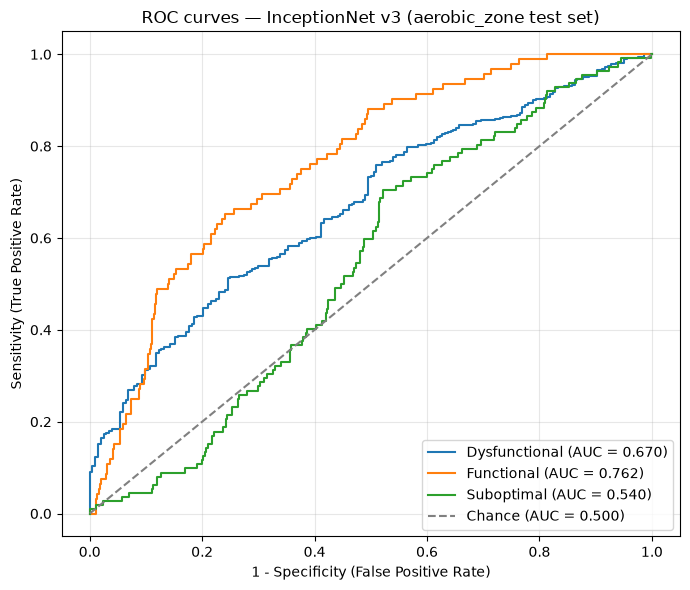

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.670
  Functional     : 0.762
  Suboptimal     : 0.540

Mean AUC (over 3/3 classes with test examples): 0.658


(np.float64(0.5509138381201044),
 {'Dysfunctional': 0.6704696113320773,
  'Functional': 0.7624177525480583,
  'Suboptimal': 0.5402331804281345})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "InceptionNet v3", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("InceptionNet v3", "inception_v3")

Saved results to ../results/aerobic_zone_aug/results_aerobic_zone_inception_v3_CapeFlats.pkl
Saved model weights to ../models/aerobic_zone_inception_v3_cnn.pt
